In [27]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import os
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor as SklearnGBR
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
from xgboost import XGBRegressor
import optuna
from optuna.importance import get_param_importances
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

### Task 1.1 - Gradient Boosting Implementation

### Decision Stump Regressor: Implementation Overview

A **Decision Stump** is a 1-depth decision tree that makes a single split on one feature. It serves as a weak learner for Gradient Boosting.

* **Initialization (`__init__`):** Sets up variables to store the optimal split parameters: the best column (`feature_index`), the split point (`threshold`), and the mean target predictions for the resulting branches (`left_value` and `right_value`).
* **Training (`fit`):** Searches across all features and their unique values to find the single split that minimizes the Mean Squared Error (MSE):
$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$
For each candidate split, it divides the data into left ($\leq$ threshold) and right ($>$ threshold) groups. The predicted value for each group is the mean of its target values. The split with the lowest MSE is saved as the model's best. 
* **Inference (`predict`):** prediction that applies the learned threshold to new data, mapping rows to either the `left_value` or `right_value`.

In [28]:
class DecisionStumpRegressor:
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        self.stumpts = []
        _, n_features = X.shape
        best_error = float("inf")

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])

            for t in thresholds:
                left_mask = X[:, feature] <= t
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                left_mean = y[left_mask].mean()
                right_mean = y[right_mask].mean()

                predictions = np.where(left_mask, left_mean, right_mean)
                error = np.mean((y-predictions) ** 2)

                if error < best_error:
                    best_error = error
                    self.feature_index = feature
                    self.threshold = t
                    self.left_value = left_mean
                    self.right_value = right_mean
    
    def predict(self, X):
        mask = X[:, self.feature_index] <= self.threshold
        return np.where(mask, self.left_value, self.right_value)

### Gradient Boosting Regressor: Implementation Overview

Gradient Boosting builds an ensemble of weak learners sequentially. Each new model attempts to correct the errors (residuals) made by the combination of all previous models.

* **Initialization (`__init__`):** Sets the hyperparameters (`n_estimators`, `learning_rate`) and prepares an empty list to store the trained decision stumps.
* **Training (`fit`):** 1. Starts with a baseline prediction, $F_0$, which is simply the mean of the target variable $y$.
  2. In a loop, it calculates the residuals (the difference between the actual $y$ and the current combined predictions). 
  3. A new `DecisionStumpRegressor` is trained specifically to predict these residuals.
  4. The model's overall predictions are updated by adding the new stump's output, scaled down by the `learning_rate` to prevent overfitting.
* **Inference (`predict`):** To predict new data, it starts with the baseline $F_0$ and loops through the saved ensemble of stumps, adding each stump's scaled prediction to compute the final value.

In [29]:
class MyGradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.stumps = []
        self.F0 = None

    def fit(self, X, y):
        self.F0 = np.mean(y)
        current_pred = np.full(len(y), self.F0)

        for _ in range(self.n_estimators):
            residuals = y - current_pred         
            stump = DecisionStumpRegressor()
            stump.fit(X, residuals)                    
            current_pred += self.learning_rate * stump.predict(X)
            self.stumps.append(stump)

    def predict(self, X):
        predictions = np.full(X.shape[0], self.F0)
        for stump in self.stumps:
            predictions += self.learning_rate * stump.predict(X)
        return predictions



### Model Evaluation: Custom vs. Scikit-Learn

This section benchmarks tests our model versus scikit Gradient Boosting

* **Data Preparation:** Loads the dataset and performs a standard 80/20 train-test split.
* **Model Training:** Trains both `MyGradientBoosting` and the Sklearn model using identical hyperparameters (`n_estimators=100`, `learning_rate=0.1`).  `max_depth=1` used in Sklearn model to force it to use Decision Stumps.
* **Evaluation:** Calculates the Mean Squared Error (MSE) for both models to evaluate accuracy.

In [30]:
data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

our_model = MyGradientBoosting(n_estimators=100, learning_rate=0.1)
our_model.fit(X_train, y_train)
our_preds = our_model.predict(X_test)
our_mse = mean_squared_error(y_test, our_preds)

sklearn_model = SklearnGBR(n_estimators=100, learning_rate=0.1, max_depth=1)
sklearn_model.fit(X_train, y_train)
sklearn_preds = sklearn_model.predict(X_test)
sklearn_mse = mean_squared_error(y_test, sklearn_preds)

print(f"Our GBR MSE:     {our_mse:.4f}")
print(f"Sklearn GBR MSE: {sklearn_mse:.4f}")
print(type(our_model))
print(type(sklearn_model))
print("Our predictions:",      our_preds[:5])
print("Sklearn predictions:",  sklearn_preds[:5])
print("Our F0:",               our_model.F0)
print("Number of stumps:",     len(our_model.stumps))

Our GBR MSE:     0.4893
Sklearn GBR MSE: 0.4893
<class '__main__.MyGradientBoosting'>
<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Our predictions: [1.14605542 1.48527216 2.83745138 2.72469427 2.21076568]
Sklearn predictions: [1.14605542 1.48527216 2.83745138 2.72469427 2.21076568]
Our F0: 2.071946937378876
Number of stumps: 100


### Custom Model Validation Results

We compared our custom Gradient Boosting Regressor (`MyGradientBoosting`) with the standard scikit-learn implementation to verify its correctness. 

Here is a summary of the results:

* **Prediction Accuracy:** Both models achieved the exact same Mean Squared Error (`0.4893`). Furthermore, the first five predictions generated by both models are identical.

**Conclusion:** The custom implementation successfully replicates the behavior and output of scikit-learn's Gradient Boosting Regressor when using decision stumps (`max_depth=1`).

### Comparing Gradient Boosting Models

This section runs a comparison of XGBoost, LightGBM, and CatBoost to see how they perform on the same dataset with identical settings.

* **Data Preparation:** Loads the data, applies a log-transform to the house prices (to handle large skews), and fills missing categorical values with 'Missing' so the models don't crash during training.
* **Model Setup:** Initializes all three models with the exact same hyperparameters (500 trees, 0.05 learning rate, max depth of 6) to ensure a fair comparison. 
* **Training and Tracking:** Runs a 5-Fold Cross-Validation loop. For each fold and model, it actively tracks how long the training takes (speed), how much RAM it consumes (memory), and its prediction error (RMSE).
* **Results:** Calculates the average performance across all 5 folds, prints a summary table of the metrics, and plots the top 5 most important features according to each algorithm.

Model        | Avg Time (s)    | Avg Mem (MB)    | Avg RMSE (log)
-----------------------------------------------------------------
XGBoost      | 3.5350          | 8.3016          | 0.1412
LightGBM     | 0.8120          | 3.2313          | 0.1324
CatBoost     | 33.6925         | 8.1539          | 0.1279


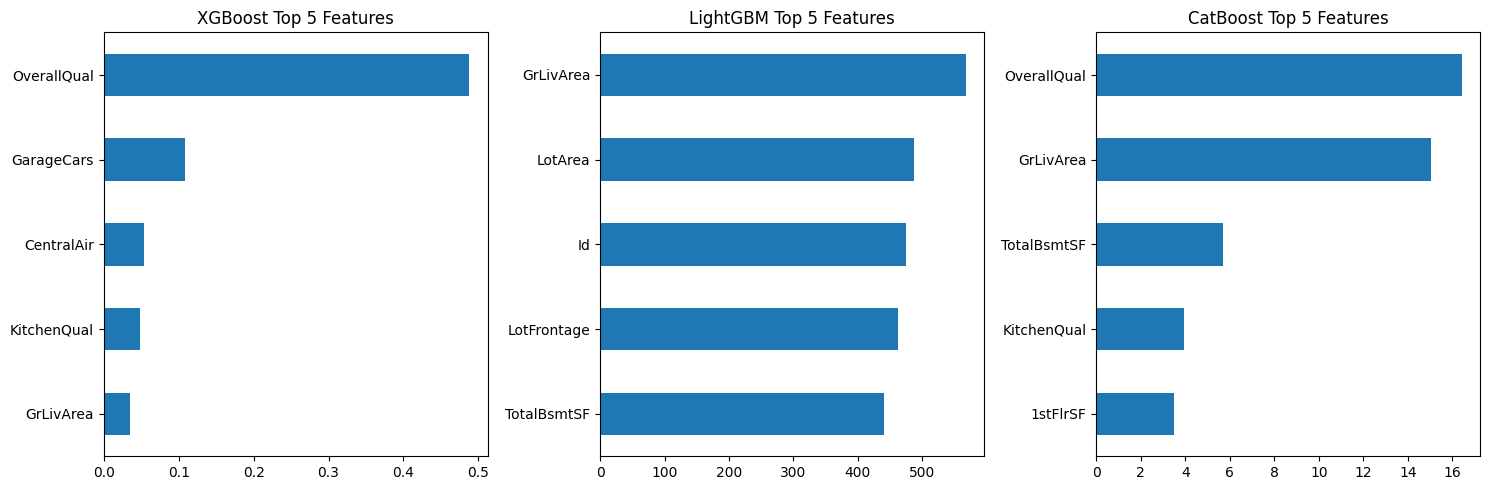

In [31]:
np.random.seed(42)
df = pd.read_csv("train.csv")

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

y_log = np.log1p(y)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].fillna('Missing') 
    X[col] = X[col].astype('category')

models = {
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        enable_categorical=True, 
        tree_method='hist'
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': cb.CatBoostRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        cat_features=categorical_cols, 
        verbose=0
    )
}

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

results = {name: {'time': [], 'memory_mb': [], 'rmse': [], 'importances': np.zeros(X.shape[1])} for name in models}

def get_memory_rss():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]
    
    for name, model in models.items():
        mem_before = get_memory_rss()
        start_time = time.time()
        
        model.fit(X_train, y_train)
        
        fit_time = time.time() - start_time
        mem_after = get_memory_rss()
        memory_used_mb = (mem_after - mem_before) / (1024 * 1024)
        
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        
        results[name]['time'].append(fit_time)
        results[name]['memory_mb'].append(max(0, memory_used_mb))
        results[name]['rmse'].append(rmse)
        
        results[name]['importances'] += model.feature_importances_ / n_splits

print(f"{'Model':<12} | {'Avg Time (s)':<15} | {'Avg Mem (MB)':<15} | {'Avg RMSE (log)'}")
print("-" * 65)
for name in models:
    avg_time = np.mean(results[name]['time'])
    avg_mem = np.mean(results[name]['memory_mb'])
    avg_rmse = np.mean(results[name]['rmse'])
    print(f"{name:<12} | {avg_time:<15.4f} | {avg_mem:<15.4f} | {avg_rmse:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, name in enumerate(models):
    importances = pd.Series(results[name]['importances'], index=X.columns).sort_values(ascending=True).tail(5)
    importances.plot(kind='barh', ax=axes[idx], title=f"{name} Top 5 Features")

plt.tight_layout()
plt.show()

### Model Performance Summary

We tested three models (XGBoost, LightGBM, and CatBoost) to predict housing prices. Here is how they compared based on speed, memory usage, and accuracy (RMSE):

* **CatBoost:** Most accurate (lowest error at `0.1279`), but by far the slowest to train (~34 seconds).
* **LightGBM:** The best all-rounder. It was incredibly fast (under 1 second), used the least memory (~3.2 MB), and had strong accuracy (`0.1324`).
* **XGBoost:** Decent speed (~3.5 seconds) but had the highest error (`0.1412`) and used the most memory (~8.3 MB).

**Conclusion:** **LightGBM** is the most efficient choice, offering a great balance of speed and accuracy. **CatBoost** is the best option if you only care about getting the lowest possible error and don't mind longer wait times. 


## Data loading

We use the file `train.csv`. The target variable is `SalePrice`.
Additionally, we remove `Id` and apply a transformation of the target:
$$
y_{log} = \log(1 + SalePrice)
$$
which usually improves regression stability for this dataset, due to "linearization" of outlayers. Thanks to this, the model will be penalized more for a $10,000 mistake at a price of $100,000 than for the same mistake at a price of $1,000,000, which seems like a reasonable approach.

In [32]:
DATA_PATH = r"train.csv"
TARGET = "SalePrice"

house_df = pd.read_csv(DATA_PATH)
X = house_df.drop(columns=[TARGET]).copy()
y = house_df[TARGET].copy()

if "Id" in X.columns:
    X = X.drop(columns=["Id"])

y_log = np.log1p(y)

print(f"Number of observations: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
X.head()

Number of observations: 1460
Number of features: 79


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## Train/test split

We split the dataset into test and training sets in the ratio 1 to 4.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1168, 79)
X_test: (292, 79)


## Data preprocessing

The dataset contains numerical and categorical features as well as missing values, which for numerical variables are imputed with the median, and for categorical variables replaced with the mode. What is more we use OneHotEncoder.

In [34]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Categorical features:", len(numeric_features))
print("Numerical features:", len(categorical_features))

Categorical features: 36
Numerical features: 43


## Helper functions

We create functions to compute metrics, generate out-of-fold predictions (OOF) and train base models.
Metrics are computed both in logarithmic scale, and after transforming back to the price scale.

In [35]:
def regression_report(y_true_log, y_pred_log):
    rmse_log = mean_squared_error(y_true_log, y_pred_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2 = r2_score(y_true_log, y_pred_log)

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    return {
        "RMSE_log": rmse_log,
        "MAE_log": mae_log,
        "R2_log": r2,
        "RMSE": rmse,
        "MAE": mae,
    }


def generate_oof_predictions(models, X, y, cv, preprocess):
    oof_matrix = np.zeros((X.shape[0], len(models)))
    model_names = list(models.keys())

    for model_idx, model_name in enumerate(model_names):
        model = models[model_name]
        print(f"Generating OOF for: {model_name}")
        for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
            y_tr = y.iloc[train_idx]

            pipe = Pipeline([
                ("prep", preprocess),
                ("model", clone(model))
            ])
            pipe.fit(X_tr, y_tr)
            oof_matrix[valid_idx, model_idx] = pipe.predict(X_val)
            print(f"  fold {fold_idx} completed")

    return oof_matrix, model_names


def fit_models_full(models, X_train, y_train, X_test, preprocess):
    preds = {}
    fitted = {}
    for model_name, model in models.items():
        pipe = Pipeline([
            ("prep", preprocess),
            ("model", clone(model))
        ])
        pipe.fit(X_train, y_train)
        preds[model_name] = pipe.predict(X_test)
        fitted[model_name] = pipe
    return fitted, preds

# Problem 1.3 — Stacked Ensemble

## Level 0 models

As per the task description, we use:
**Random Forest**,
**XGBoost**,
**Neural Network - Multi Layer Perceptron**.

For MLP, we transform the data separately using `StandardScaler`, as neural networks typically perform better on scaled data.

In [36]:
mlp_preprocessor = Pipeline([
    ("prep", preprocessor),
    ("scaler", StandardScaler(with_mean=False))
])

base_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
    ),
}

mlp_model = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=400,
    early_stopping=True,
    random_state=42,
)

## Out of fold predictions
They create several (in our case 5) subsets of the training set to then train the same number of independent models, each of them using a different subset as a test set.

In [37]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# OOF dla RF i XGB
basic_oof, basic_names = generate_oof_predictions(base_models, X_train, y_train, cv, preprocessor)

# OOF dla MLP osobno
print("Generating OOF for: Neural Network")
oof_mlp = np.zeros(X_train.shape[0])
for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_tr = y_train.iloc[train_idx]

    mlp_pipe = Pipeline([
        ("prep", mlp_preprocessor),
        ("model", clone(mlp_model))
    ])
    mlp_pipe.fit(X_tr, y_tr)
    oof_mlp[valid_idx] = mlp_pipe.predict(X_val)
    print(f"  fold {fold_idx} completed")

stack_X_train = pd.DataFrame(
    np.column_stack([basic_oof, oof_mlp]),
    columns=["rf_oof", "xgb_oof", "mlp_oof"],
    index=X_train.index
)
stack_X_train.head()

Generating OOF for: Random Forest
  fold 1 completed
  fold 2 completed
  fold 3 completed
  fold 4 completed
  fold 5 completed
Generating OOF for: XGBoost
  fold 1 completed
  fold 2 completed
  fold 3 completed
  fold 4 completed
  fold 5 completed
Generating OOF for: Neural Network
  fold 1 completed
  fold 2 completed
  fold 3 completed
  fold 4 completed
  fold 5 completed


,rf_oof,xgb_oof,mlp_oof
254,11.891864,11.878708,11.817835
1066,12.058068,12.078074,12.101997
638,11.475391,11.453282,11.638187
799,11.881385,11.925592,11.862809
380,11.812882,11.892522,12.177383


## Meta-learner (level 1)

At Level 1, we use **Ridge Regression** as specified in the task. The model learns to combine the predictions of the underlying models into a single final forecast.

In [38]:
meta_learner = Ridge(alpha=1.0)
meta_learner.fit(stack_X_train, y_train)

print("Coefficients of the meta-model:")
for name, coef in zip(stack_X_train.columns, meta_learner.coef_):
    print(f"{name:10s}: {coef:.4f}")
print(f"intercept : {meta_learner.intercept_:.4f}")

Coefficients of the meta-model:
rf_oof    : -0.0040
xgb_oof   : 0.9525
mlp_oof   : 0.0704
intercept : -0.2250


## Predictions on the Test Set

We now train each baseline model on the full training set and then generate predictions on `X_test`. These three predictions are fed into the meta-learner.

In [39]:
_, base_test_preds = fit_models_full(base_models, X_train, y_train, X_test, preprocessor)

mlp_pipe_full = Pipeline([
    ("prep", mlp_preprocessor),
    ("model", clone(mlp_model))
])
mlp_pipe_full.fit(X_train, y_train)
mlp_test_pred = mlp_pipe_full.predict(X_test)

stack_X_test = pd.DataFrame({
    "rf_oof": base_test_preds["Random Forest"],
    "xgb_oof": base_test_preds["XGBoost"],
    "mlp_oof": mlp_test_pred,
}, index=X_test.index)

stack_test_pred = meta_learner.predict(stack_X_test)
stack_X_test.head()

,rf_oof,xgb_oof,mlp_oof
892,11.851525,11.853329,11.819118
1105,12.657704,12.731780,12.797959
413,11.648045,11.644350,11.427781
522,11.934033,11.949039,11.938287
1036,12.672055,12.737134,12.605401


## Comparison with baseline models

We verify whether mtea-learner produces better results than individual models.

In [40]:
results_13 = []

for model_name, pred in {
    "Random Forest": base_test_preds["Random Forest"],
    "XGBoost": base_test_preds["XGBoost"],
    "Neural Network": mlp_test_pred,
    "Stacked Ensemble": stack_test_pred,
}.items():
    row = regression_report(y_test, pred)
    row["Model"] = model_name
    results_13.append(row)

results_13_df = pd.DataFrame(results_13)
results_13_df = results_13_df[["Model", "RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE"]]
results_13_df.sort_values("RMSE_log")

,Model,RMSE_log,MAE_log,R2_log,RMSE,MAE
3,Stacked Ensemble,0.016267,0.085626,0.912829,6.339744e+08,15128.236979
1,XGBoost,0.017058,0.086926,0.908592,6.847265e+08,15468.125562
0,Random Forest,0.021331,0.097948,0.885693,8.596084e+08,17345.852838
2,Neural Network,0.024118,0.113556,0.870760,9.260828e+08,20343.609379


## Commentary on Problem 1.3

We see that the meta-learner achieved the lowest RMSE_log, which means that Ridge regression effectively combined the baseline models. However, we also know that the XGBoost model received by far the highest weight and it achieved a result similar to the meta-learner.


# Problem 1.4 – Bayesian Optimization with Optuna

## Data preprocessing for XGBoost

To compare Optuna and Random Search, we use the same preprocessing and cross-validation procedure.
This ensures a fair comparison of both hyperparameter search methods.

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Matrix after preprocessing:", X_train_processed.shape)

Matrix after preprocessing: (1168, 285)


## CV Evaluation Function

The following function returns the mean RMSE_log from cross-validation for a given set of XGBoost parameters.
We optimize exactly eight hyperparameters.

In [42]:
def evaluate_xgb_cv(params, X_data, y_data, cv):
    rmses = []
    for train_idx, valid_idx in cv.split(X_data, y_data):
        X_tr = X_data[train_idx]
        X_val = X_data[valid_idx]
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            **params
        )
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        rmse = mean_squared_error(y_val, pred)
        rmses.append(rmse)
    return float(np.mean(rmses))

## Optuna 

Optuna intelligently selects subsequent sets of parameters based on previous results. This distinguishes it from simple random sampling.

In [43]:
def optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    return evaluate_xgb_cv(params, X_train_processed, y_train, cv)

## Launching Optuna

According to the task, we perform 100 trials.

In [44]:
N_TRIALS = 100

study = optuna.create_study(direction="minimize", study_name="xgb_optuna_house_prices")
start_time = time.time()
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=False)
optuna_time = time.time() - start_time

print("Best Optuna result (CV RMSE_log):", study.best_value)
study.best_params

[I 2026-03-19 23:04:03,480] A new study created in memory with name: xgb_optuna_house_prices
[I 2026-03-19 23:04:08,398] Trial 0 finished with value: 0.016819672669935327 and parameters: {'n_estimators': 249, 'learning_rate': 0.024502393268805427, 'max_depth': 5, 'min_child_weight': 12, 'subsample': 0.8929498528313476, 'colsample_bytree': 0.5468193235274798, 'reg_alpha': 4.337831403720132e-06, 'reg_lambda': 3.649928603496599e-07}. Best is trial 0 with value: 0.016819672669935327.
[I 2026-03-19 23:04:26,393] Trial 1 finished with value: 0.017102876710340813 and parameters: {'n_estimators': 721, 'learning_rate': 0.05768853366885942, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.61114096906868, 'colsample_bytree': 0.5262607633642612, 'reg_alpha': 2.343899898968169e-08, 'reg_lambda': 6.005975366250817e-07}. Best is trial 0 with value: 0.016819672669935327.
[I 2026-03-19 23:04:41,695] Trial 2 finished with value: 0.016233470189283592 and parameters: {'n_estimators': 871, 'learning_r

Best Optuna result (CV RMSE_log): 0.015077860245418259


{'n_estimators': 627,
 'learning_rate': 0.08438873988603791,
 'max_depth': 2,
 'min_child_weight': 10,
 'subsample': 0.6048320164608897,
 'colsample_bytree': 0.7737485099490836,
 'reg_alpha': 3.489899034965611e-05,
 'reg_lambda': 9.582502138484515e-08}

## Random Search - Same number of trials

For a fair comparison, we also perform 100 random trials in the same parameter space.

In [45]:
rng = np.random.default_rng(42)


def sample_random_params(rng):
    return {
        "n_estimators": int(rng.integers(150, 901)),
        "learning_rate": float(np.exp(rng.uniform(np.log(0.01), np.log(0.3)))),
        "max_depth": int(rng.integers(2, 11)),
        "min_child_weight": int(rng.integers(1, 13)),
        "subsample": float(rng.uniform(0.5, 1.0)),
        "colsample_bytree": float(rng.uniform(0.5, 1.0)),
        "reg_alpha": float(np.exp(rng.uniform(np.log(1e-8), np.log(10.0)))),
        "reg_lambda": float(np.exp(rng.uniform(np.log(1e-8), np.log(10.0)))),
    }

random_search_results = []
best_random_score = np.inf
best_random_params = None

start_time = time.time()
for i in range(N_TRIALS):
    params = sample_random_params(rng)
    score = evaluate_xgb_cv(params, X_train_processed, y_train, cv)
    random_search_results.append({"trial": i + 1, "score": score, **params})
    if score < best_random_score:
        best_random_score = score
        best_random_params = params
random_search_time = time.time() - start_time

print("Best Random Search result (CV RMSE_log):", best_random_score)
best_random_params

Best Random Search result (CV RMSE_log): 0.015673331186373138


{'n_estimators': 877,
 'learning_rate': 0.05596425205169427,
 'max_depth': 3,
 'min_child_weight': 12,
 'subsample': 0.7905583046104512,
 'colsample_bytree': 0.5998878258300289,
 'reg_alpha': 0.17263177486733927,
 'reg_lambda': 0.027457700688272083}

## Optimization History

We plot the best result achieved for a given trials.


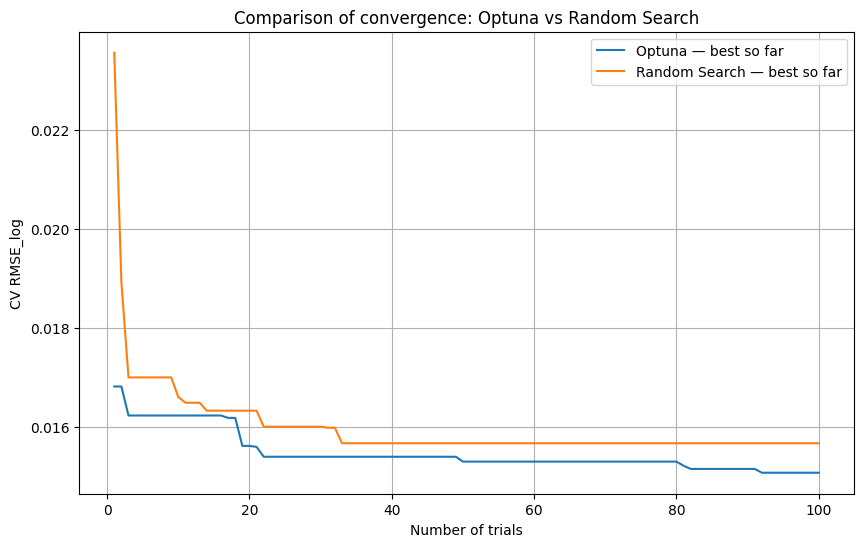

In [46]:
optuna_history = pd.DataFrame({
    "trial": [t.number + 1 for t in study.trials],
    "score": [t.value for t in study.trials],
})
optuna_history["best_so_far"] = optuna_history["score"].cummin()

random_history = pd.DataFrame(random_search_results)[["trial", "score"]].copy()
random_history["best_so_far"] = random_history["score"].cummin()

plt.figure(figsize=(10, 6))
plt.plot(optuna_history["trial"], optuna_history["best_so_far"], label="Optuna — best so far")
plt.plot(random_history["trial"], random_history["best_so_far"], label="Random Search — best so far")
plt.xlabel("Number of trials")
plt.ylabel("CV RMSE_log")
plt.title("Comparison of convergence: Optuna vs Random Search")
plt.legend()
plt.grid(True)
plt.show()

## Hyperparameter Importance

Optuna allows you to estimate which hyperparameters had the greatest impact on the model's results. 

In [47]:
param_importance = get_param_importances(study)
importance_df = pd.DataFrame(
    list(param_importance.items()),
    columns=["parameter", "importance"]
).sort_values("importance", ascending=False)
importance_df

,parameter,importance
0,reg_alpha,0.538169
1,learning_rate,0.198202
2,subsample,0.138301
3,max_depth,0.095611
4,colsample_bytree,0.017700
5,n_estimators,0.009309
6,min_child_weight,0.001629
7,reg_lambda,0.001078


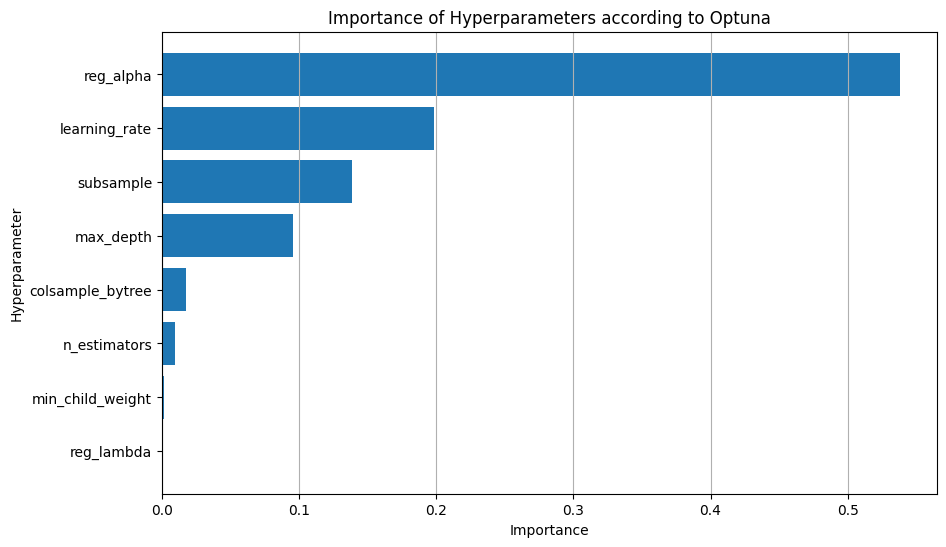

In [48]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["parameter"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Hyperparameter")
plt.title("Importance of Hyperparameters according to Optuna")
plt.grid(axis="x")
plt.show()

## Final models with the best parameters

We train two final XGBoost models:

with the best parameters from Optuna,

with the best parameters from Random Search,

and then compare them on the test set.

In [49]:
best_optuna_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **study.best_params
)
best_optuna_model.fit(X_train_processed, y_train)
best_optuna_pred = best_optuna_model.predict(X_test_processed)

best_random_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_random_params
)
best_random_model.fit(X_train_processed, y_train)
best_random_pred = best_random_model.predict(X_test_processed)

results_14 = []

row = regression_report(y_test, best_optuna_pred)
row["Method"] = "Optuna"
row["CV_best_RMSE_log"] = study.best_value
row["Search_time_sec"] = optuna_time
results_14.append(row)

row = regression_report(y_test, best_random_pred)
row["Method"] = "Random Search"
row["CV_best_RMSE_log"] = best_random_score
row["Search_time_sec"] = random_search_time
results_14.append(row)

results_14_df = pd.DataFrame(results_14)
results_14_df = results_14_df[["Method", "CV_best_RMSE_log", "RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE", "Search_time_sec"]]
results_14_df.sort_values("CV_best_RMSE_log")

,Method,CV_best_RMSE_log,RMSE_log,MAE_log,R2_log,RMSE,MAE,Search_time_sec
0,Optuna,0.015078,0.017995,0.090686,0.903572,7.225156e+08,16066.959265,975.206902
1,Random Search,0.015673,0.017853,0.087682,0.904333,6.870360e+08,15456.965138,1202.527684


## Comment on Problem 1.4

Optuna achieves a better result than Random Search with the same number of trials
because it uses information from previous evaluations. Parameter importance analysis also allows us
to see which hyperparameters are actually important for the model. However, in our case, Random Search performed only slightly worse on both the training and test sets.